In [1]:
import numpy as np
import os
import torch

from configuration.rte1d_setting import get_config
from modules.networks import ResNet_1d, Xavier_initi
from constraints.rte_eqn import OERTE1D

In [2]:
cfg = get_config()
kn = 1.0e-2
device_ids = cfg.model.device_ids
device = torch.device(
    "cuda:{:d}".format(device_ids[0]) if torch.cuda.is_available() else "cpu"
)
print(f"Using device: {device}")
model_config = cfg.model

Using device: cuda:0


In [3]:
j_nn = ResNet_1d(
    input_size=model_config["fn_j"]["input_size"],
    hidden_sizes=model_config["fn_j"]["hidden_sizes"],
    output_size=model_config["fn_j"]["output_size"],
    device=device,
)
r_nn = ResNet_1d(
    input_size=model_config["fn_r"]["input_size"],
    hidden_sizes=model_config["fn_r"]["hidden_sizes"],
    output_size=model_config["fn_r"]["output_size"],
    device=device,
)

/home/sheny-y23/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


In [4]:
model_ckpt_path = "./ckpts/"
os.makedirs(model_ckpt_path, exist_ok=True)

# Load pretrained parameters if available, otherwise initialize with Xavier
for model, name in [
    (j_nn, f"j_nn_ex1_params_{kn:.1e}.pt"),
    (r_nn, f"r_nn_ex1_params_{kn:.1e}.pt"),
]:
    ckpt_file = os.path.join(model_ckpt_path, name)

    if os.path.isfile(ckpt_file):
        model.load_state_dict(torch.load(ckpt_file, map_location=device))
        print(f"[Model Parameters] Loaded pretrained weights: {ckpt_file}")
    else:
        print(
            f"[Model Parameters] Pretrained weights not found, initializing with Xavier: {ckpt_file}"
        )
        Xavier_initi(model)

[Model Parameters] Loaded pretrained weights: ./ckpts/j_nn_ex1_params_1.0e-02.pt
[Model Parameters] Loaded pretrained weights: ./ckpts/r_nn_ex1_params_1.0e-02.pt


In [5]:
rte_constraint = OERTE1D(cfg)

In [6]:
# load data
data = np.load(f"./data/rte1d_ex1_ref_{kn:.1e}.npz")
mesh_x = data["mesh_x"]  # [Nx,]
mesh_v = data["mesh_v"]  # [Nv,]
mesh_xx, mesh_vv = np.meshgrid(mesh_x, mesh_v, indexing="ij")
mesh_xx = torch.from_numpy(mesh_xx).float().reshape(-1, 1)
mesh_vv = torch.from_numpy(mesh_vv).float().reshape(-1, 1)
F_ref = data["F"]
F_ref.shape

(254, 511)

In [7]:
# 保证模型和输入都在同一 device
mesh_xx = mesh_xx.to(device)
mesh_vv = mesh_vv.to(device)
j_nn = j_nn.to(device)
r_nn = r_nn.to(device)
j_app = rte_constraint.model_j(j_nn, [mesh_xx, mesh_vv]).detach().cpu().numpy()
r_app = rte_constraint.model_r(r_nn, [mesh_xx, mesh_vv]).detach().cpu().numpy()
f_app = kn * j_app + r_app
print(f_app.shape)

(129794, 1)


In [8]:
Nx = len(mesh_x)
Nv = len(mesh_v)
X, V = np.meshgrid(mesh_x, mesh_v, indexing="ij")
F = F_ref.T
F_hat = f_app.reshape(Nx, Nv)

In [9]:
err_f = np.linalg.norm(F - F_hat) / np.linalg.norm(F)
print(f"Relative L2 Error in f: {err_f:.3e}")

Relative L2 Error in f: 3.030e-03


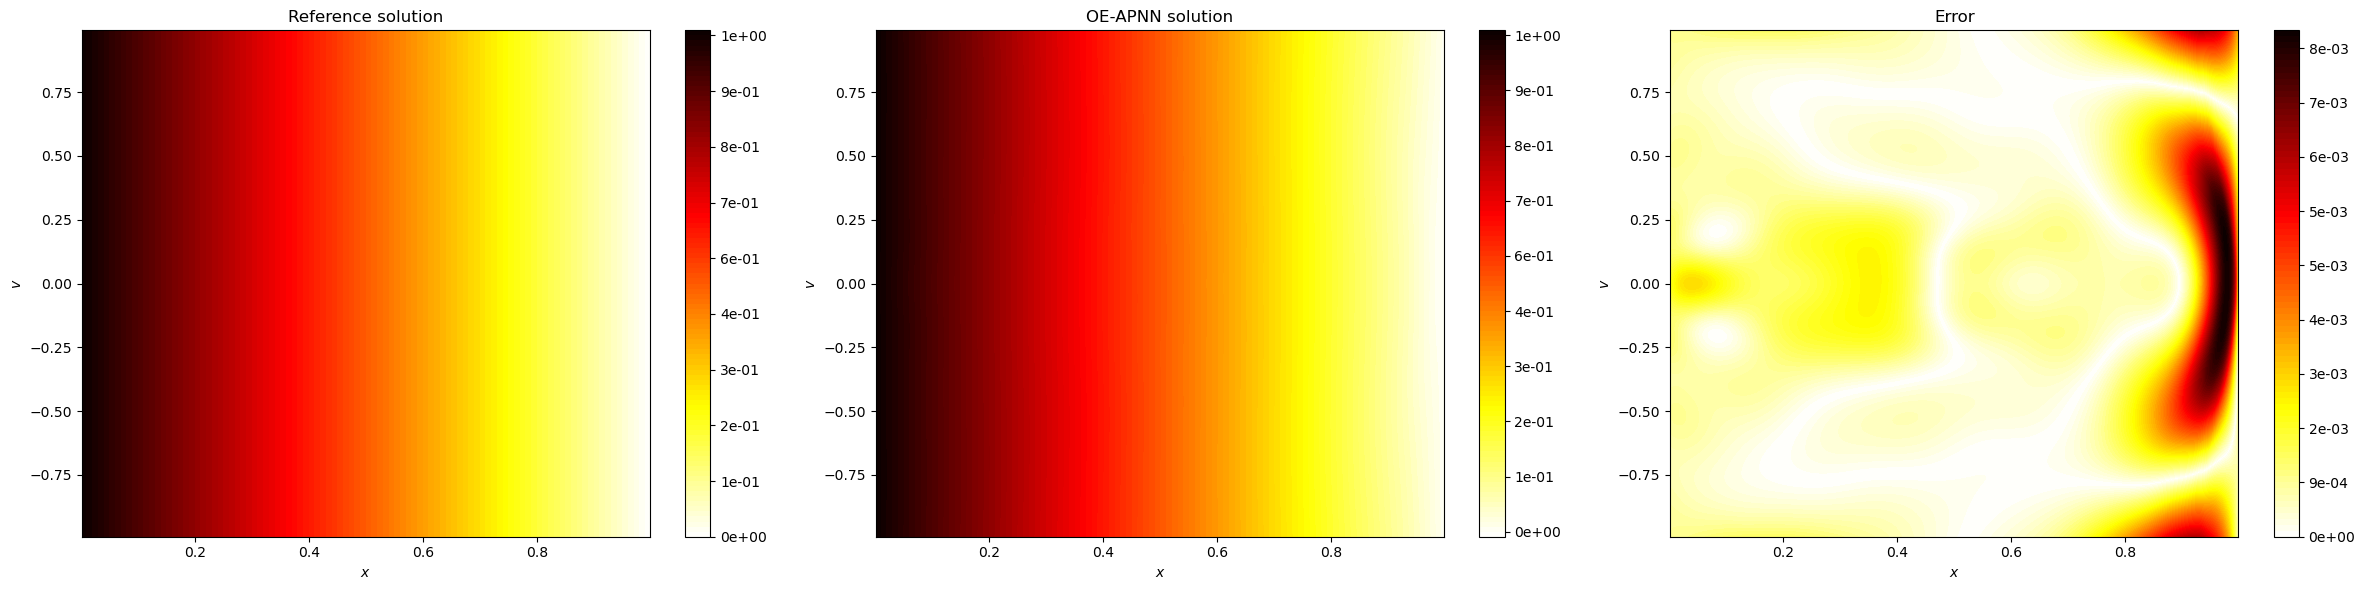

In [10]:
import matplotlib.pyplot as plt


plt.figure(figsize=(24, 6))
ax1 = plt.subplot(1, 3, 1)
c1 = ax1.contourf(X, V, F, 100, cmap="hot_r")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$v$")
plt.colorbar(c1, ax=ax1, format="%.0e")
ax1.set_title("Reference solution")

ax2 = plt.subplot(1, 3, 2)
c2 = ax2.contourf(X, V, F_hat, 100, cmap="hot_r")
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$v$")
plt.colorbar(c2, ax=ax2, format="%.0e")
ax2.set_title("OE-APNN solution")

ax3 = plt.subplot(1, 3, 3)
c3 = ax3.contourf(X, V, np.abs(F - F_hat), 100, cmap="hot_r")
ax3.set_xlabel(r"$x$")
ax3.set_ylabel(r"$v$")
plt.colorbar(c3, ax=ax3, format="%.0e")
ax3.set_title("Error")

# for ax in [ax1, ax2, ax3]:
#     ax.spines["bottom"].set_linewidth(2)
#     ax.spines["left"].set_linewidth(2)
#     ax.spines["right"].set_linewidth(2)
#     ax.spines["top"].set_linewidth(2)

plt.tight_layout()
plt.show()
plt.close()

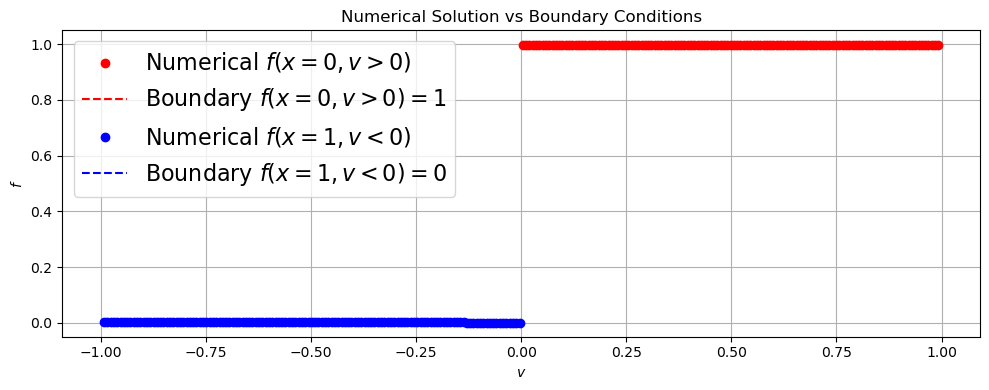

In [11]:
# 数值解与边界条件对比
plt.figure(figsize=(10, 4))

# x=0, v>0
v_pos = mesh_v[mesh_v > 0]
idx_x0 = 0
f_num_left = F_hat[idx_x0, mesh_v > 0]
plt.plot(v_pos, f_num_left, "ro", label=r"Numerical $f(x=0, v>0)$")
plt.plot(v_pos, np.ones_like(v_pos), "r--", label=r"Boundary $f(x=0, v>0)=1$")

# x=1, v<0
v_neg = mesh_v[mesh_v < 0]
idx_x1 = -1
f_num_right = F_hat[idx_x1, mesh_v < 0]
plt.plot(v_neg, f_num_right, "bo", label=r"Numerical $f(x=1, v<0)$")
plt.plot(v_neg, np.zeros_like(v_neg), "b--", label=r"Boundary $f(x=1, v<0)=0$")

plt.xlabel(r"$v$")
plt.ylabel(r"$f$")
plt.title("Numerical Solution vs Boundary Conditions")
plt.legend(fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()

findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.


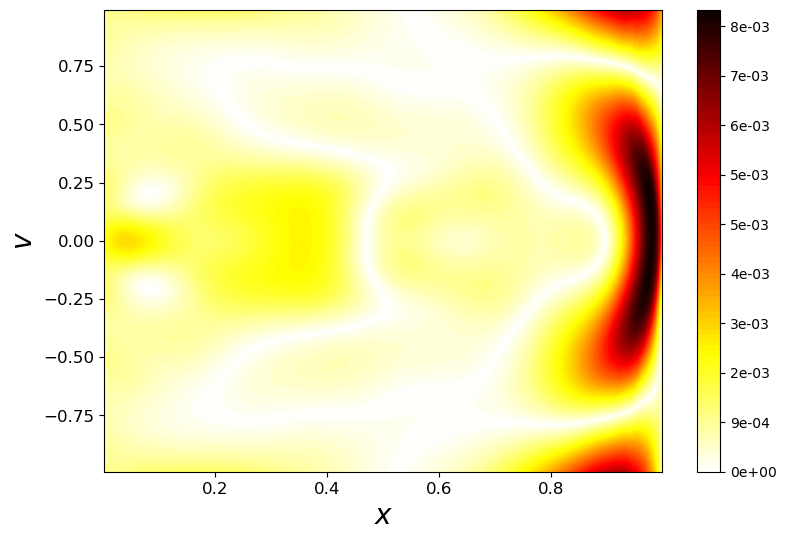

In [12]:
fig = plt.figure(figsize=(9, 6))
plt.contourf(X, V, np.abs(F - F_hat), 100, cmap="hot_r")
plt.xticks(fontproperties="Times New Roman", size=12)
plt.yticks(fontproperties="Times New Roman", size=12)
plt.xlabel(r"$x$", size=20)
plt.ylabel(r"$v$", size=20)
plt.colorbar(format="%.0e")
plt.show()

In [13]:
j_nn = ResNet_1d(
    input_size=model_config["fn_j"]["input_size"],
    hidden_sizes=model_config["fn_j"]["hidden_sizes"],
    output_size=model_config["fn_j"]["output_size"],
    device=device,
)
r_nn = ResNet_1d(
    input_size=model_config["fn_r"]["input_size"],
    hidden_sizes=model_config["fn_r"]["hidden_sizes"],
    output_size=model_config["fn_r"]["output_size"],
    device=device,
)

In [27]:
model_ckpt_path = "./ckpts/"
os.makedirs(model_ckpt_path, exist_ok=True)
kn = 1.0e-1
rte_constraint = OERTE1D(cfg)

# Load pretrained parameters if available, otherwise initialize with Xavier
for model, name in [
    (j_nn, f"j_nn_ex2_params_{kn:.1e}.pt"),
    (r_nn, f"r_nn_ex2_params_{kn:.1e}.pt"),
]:
    ckpt_file = os.path.join(model_ckpt_path, name)

    if os.path.isfile(ckpt_file):
        model.load_state_dict(torch.load(ckpt_file, map_location=device))
        print(f"[Model Parameters] Loaded pretrained weights: {ckpt_file}")
    else:
        print(
            f"[Model Parameters] Pretrained weights not found, initializing with Xavier: {ckpt_file}"
        )
        Xavier_initi(model)

[Model Parameters] Loaded pretrained weights: ./ckpts/j_nn_ex2_params_1.0e-01.pt
[Model Parameters] Loaded pretrained weights: ./ckpts/r_nn_ex2_params_1.0e-01.pt


In [28]:
# load data
data = np.load(f"./data/rte1d_ex2_ref_{kn:.1e}.npz")
mesh_x = data["mesh_x"]  # [Nx,]
mesh_v = data["mesh_v"]  # [Nv,]
mesh_xx, mesh_vv = np.meshgrid(mesh_x, mesh_v, indexing="ij")
mesh_xx = torch.from_numpy(mesh_xx).float().reshape(-1, 1)
mesh_vv = torch.from_numpy(mesh_vv).float().reshape(-1, 1)
F_ref = data["F"]
F_ref.shape

(2046, 1023)

In [29]:
# 保证模型和输入都在同一 device
mesh_xx = mesh_xx.to(device)
mesh_vv = mesh_vv.to(device)
j_nn = j_nn.to(device)
r_nn = r_nn.to(device)
j_app = rte_constraint.model_j(j_nn, [mesh_xx, mesh_vv]).detach().cpu().numpy()
r_app = rte_constraint.model_r(r_nn, [mesh_xx, mesh_vv]).detach().cpu().numpy()
f_app = kn * j_app + r_app
print(f_app.shape)

(2093058, 1)


In [30]:
Nx = len(mesh_x)
Nv = len(mesh_v)
X, V = np.meshgrid(mesh_x, mesh_v, indexing="ij")
F = F_ref.T
F_hat = f_app.reshape(Nx, Nv)

In [31]:
err_f = np.linalg.norm(F - F_hat) / np.linalg.norm(F)
print(f"Relative L2 Error in f: {err_f:.3e}")

Relative L2 Error in f: 1.868e-02


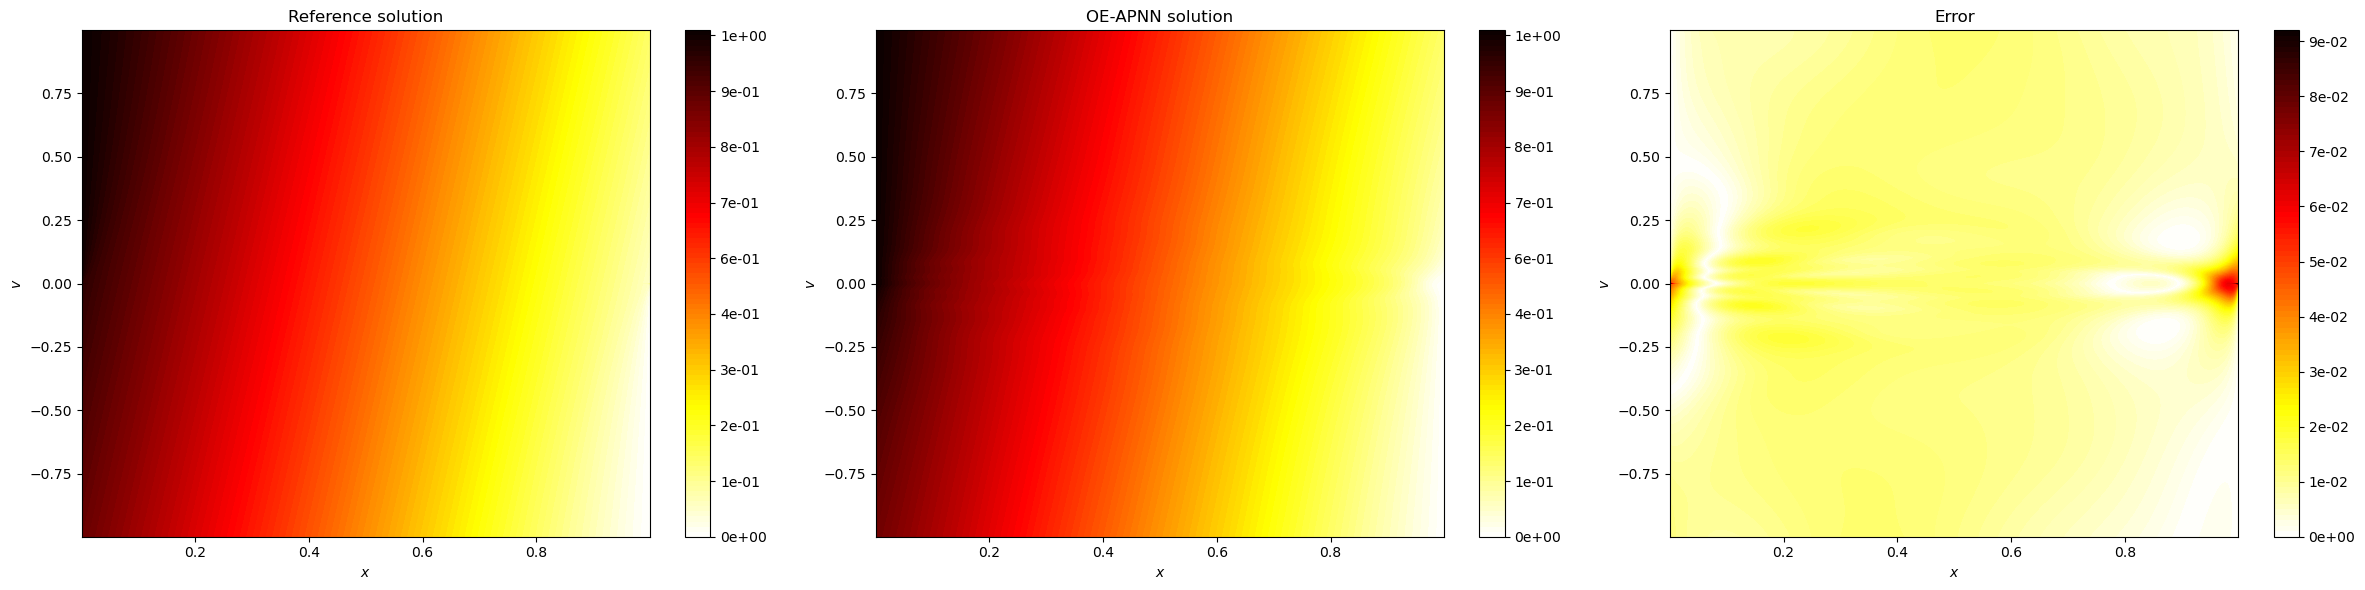

In [32]:
import matplotlib.pyplot as plt


plt.figure(figsize=(24, 6))
ax1 = plt.subplot(1, 3, 1)
c1 = ax1.contourf(X, V, F, 100, cmap="hot_r")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$v$")
plt.colorbar(c1, ax=ax1, format="%.0e")
ax1.set_title("Reference solution")

ax2 = plt.subplot(1, 3, 2)
c2 = ax2.contourf(X, V, F_hat, 100, cmap="hot_r")
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$v$")
plt.colorbar(c2, ax=ax2, format="%.0e")
ax2.set_title("OE-APNN solution")

ax3 = plt.subplot(1, 3, 3)
c3 = ax3.contourf(X, V, np.abs(F - F_hat), 100, cmap="hot_r")
ax3.set_xlabel(r"$x$")
ax3.set_ylabel(r"$v$")
plt.colorbar(c3, ax=ax3, format="%.0e")
ax3.set_title("Error")

# for ax in [ax1, ax2, ax3]:
#     ax.spines["bottom"].set_linewidth(2)
#     ax.spines["left"].set_linewidth(2)
#     ax.spines["right"].set_linewidth(2)
#     ax.spines["top"].set_linewidth(2)

plt.tight_layout()
plt.show()
plt.close()

In [20]:
j_nn = ResNet_1d(
    input_size=model_config["fn_j"]["input_size"],
    hidden_sizes=model_config["fn_j"]["hidden_sizes"],
    output_size=model_config["fn_j"]["output_size"],
    device=device,
)
r_nn = ResNet_1d(
    input_size=model_config["fn_r"]["input_size"],
    hidden_sizes=model_config["fn_r"]["hidden_sizes"],
    output_size=model_config["fn_r"]["output_size"],
    device=device,
)


In [21]:
model_ckpt_path = "./ckpts/"
os.makedirs(model_ckpt_path, exist_ok=True)
kn = 0.1
rte_constraint = OERTE1D(cfg)

# Load pretrained parameters if available, otherwise initialize with Xavier
for model, name in [
    (j_nn, f"j_nn_ex3_params_{kn:.1e}.pt"),
    (r_nn, f"r_nn_ex3_params_{kn:.1e}.pt"),
]:
    ckpt_file = os.path.join(model_ckpt_path, name)

    if os.path.isfile(ckpt_file):
        model.load_state_dict(torch.load(ckpt_file, map_location=device))
        print(f"[Model Parameters] Loaded pretrained weights: {ckpt_file}")
    else:
        print(
            f"[Model Parameters] Pretrained weights not found, initializing with Xavier: {ckpt_file}"
        )
        Xavier_initi(model)


[Model Parameters] Loaded pretrained weights: ./ckpts/j_nn_ex3_params_1.0e-01.pt
[Model Parameters] Loaded pretrained weights: ./ckpts/r_nn_ex3_params_1.0e-01.pt


In [22]:
# load data
data = np.load(f"./data/rte1d_ex3_ref_{kn:.1e}.npz")
mesh_x = data["mesh_x"]  # [Nx,]
mesh_v = data["mesh_v"]  # [Nv,]
mesh_xx, mesh_vv = np.meshgrid(mesh_x, mesh_v, indexing="ij")
mesh_xx = torch.from_numpy(mesh_xx).float().reshape(-1, 1)
mesh_vv = torch.from_numpy(mesh_vv).float().reshape(-1, 1)
F_ref = data["F"]
F_ref.shape


(2046, 1023)

In [23]:
# 保证模型和输入都在同一 device
mesh_xx = mesh_xx.to(device)
mesh_vv = mesh_vv.to(device)
j_nn = j_nn.to(device)
r_nn = r_nn.to(device)
j_app = rte_constraint.model_j(j_nn, [mesh_xx, mesh_vv]).detach().cpu().numpy()
r_app = rte_constraint.model_r(r_nn, [mesh_xx, mesh_vv]).detach().cpu().numpy()
f_app = kn * j_app + r_app
print(f_app.shape)


(2093058, 1)


In [24]:
Nx = len(mesh_x)
Nv = len(mesh_v)
X, V = np.meshgrid(mesh_x, mesh_v, indexing="ij")
F = F_ref.T
F_hat = f_app.reshape(Nx, Nv)


In [25]:
err_f = np.linalg.norm(F - F_hat) / np.linalg.norm(F)
print(f"Relative L2 Error in f: {err_f:.3e}")


Relative L2 Error in f: 3.264e-02


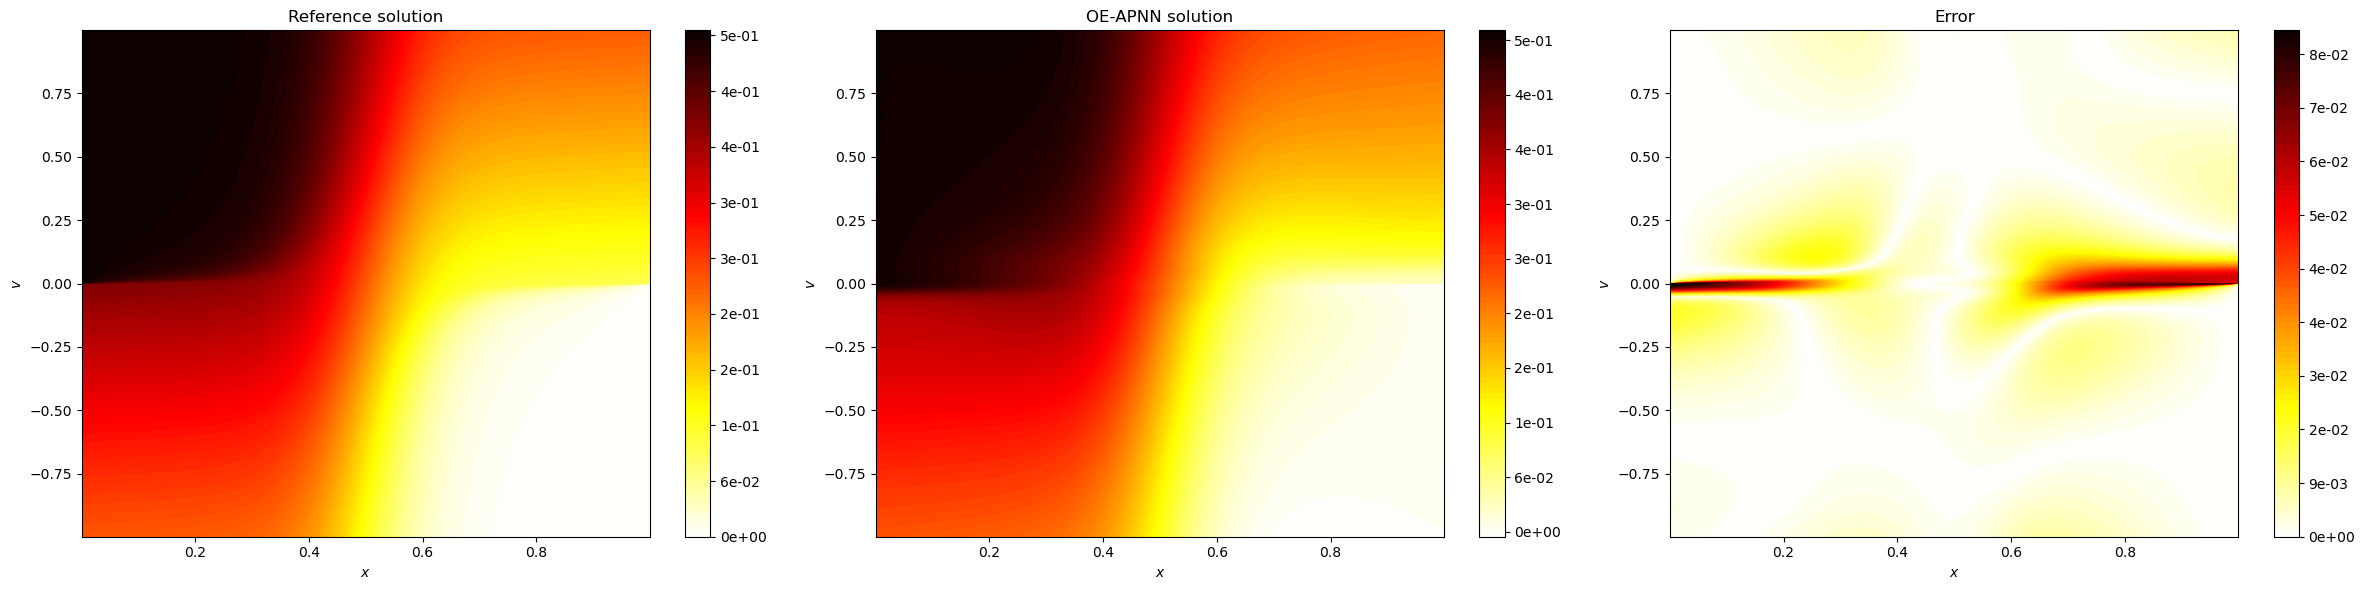

In [26]:
import matplotlib.pyplot as plt


plt.figure(figsize=(24, 6))
ax1 = plt.subplot(1, 3, 1)
c1 = ax1.contourf(X, V, F, 100, cmap="hot_r")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$v$")
plt.colorbar(c1, ax=ax1, format="%.0e")
ax1.set_title("Reference solution")

ax2 = plt.subplot(1, 3, 2)
c2 = ax2.contourf(X, V, F_hat, 100, cmap="hot_r")
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$v$")
plt.colorbar(c2, ax=ax2, format="%.0e")
ax2.set_title("OE-APNN solution")

ax3 = plt.subplot(1, 3, 3)
c3 = ax3.contourf(X, V, np.abs(F - F_hat), 100, cmap="hot_r")
ax3.set_xlabel(r"$x$")
ax3.set_ylabel(r"$v$")
plt.colorbar(c3, ax=ax3, format="%.0e")
ax3.set_title("Error")

# for ax in [ax1, ax2, ax3]:
#     ax.spines["bottom"].set_linewidth(2)
#     ax.spines["left"].set_linewidth(2)
#     ax.spines["right"].set_linewidth(2)
#     ax.spines["top"].set_linewidth(2)

plt.tight_layout()
plt.show()
plt.close()
